In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib

In [3]:
df = pd.read_csv("paysim.csv")

In [4]:
# fraud only happens in transfer and cashout columns
#so dropping all the column except transfer and cashout columns
df_filtered=df[df['type'].isin(['TRANSFER','CASH_OUT'])].copy()

In [7]:
print(f"Original shape: {df.shape}")
print(f"Optimized shape (transfer,cashout): {df_filtered.shape}")
df_filtered.head(10)

Original shape: (6362620, 11)
Optimized shape (transfer,cashout): (2770409, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.0,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.0,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.0,2719172.89,0,0
42,1,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.0,2415.16,0,0
47,1,CASH_OUT,56953.90,C1570470538,1942.02,0.0,C824009085,70253.0,64106.18,0,0
48,1,CASH_OUT,5346.89,C512549200,0.00,0.0,C248609774,652637.0,6453430.91,0,0
51,1,CASH_OUT,23261.30,C2072313080,20411.53,0.0,C2001112025,25742.0,0.00,0,0
58,1,TRANSFER,62610.80,C1976401987,79114.00,16503.2,C1937962514,517.0,8383.29,0,0


In [8]:
#performed One-hot Encoding (text/categorical data to binary data)
df_encoded = pd.get_dummies(df_filtered, columns=['type'], drop_first=True)

In [9]:
features_to_drop = ['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud']
X = df_encoded.drop(columns=features_to_drop)
y = df_encoded['isFraud']

In [11]:
#features our model is actually going to look at 
print("Features used for training:", list(X.columns))

Features used for training: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_TRANSFER']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training features shape: {X_train.shape}")

Training features shape: (2216327, 7)


In [15]:
print("Training Random Forest Model...")

model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)

Training Random Forest Model...


In [16]:
model.fit(X_train, y_train)
print("✅ Training complete!")

✅ Training complete!


In [17]:
y_pred = model.predict(X_test)

In [18]:
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    552439
           1       0.15      0.96      0.25      1643

    accuracy                           0.98    554082
   macro avg       0.57      0.97      0.62    554082
weighted avg       1.00      0.98      0.99    554082



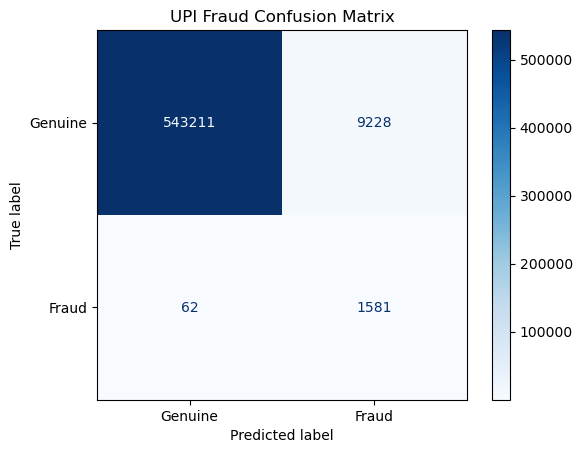

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title('UPI Fraud Confusion Matrix')
plt.show()

### True Negative:(0,0)
### False Positive:(0,1)
### False Negative:(1,0)
### True Positive:(1,1)

In [20]:
joblib.dump(model, 'upi_fraud_model.pkl')
joblib.dump(list(X_train.columns), 'model_features.pkl')

print("💾 'upi_fraud_model.pkl' and 'model_features.pkl' saved successfully!")

💾 'upi_fraud_model.pkl' and 'model_features.pkl' saved successfully!
